1. 制作数据集
2. 构建模型、定义损失函数、定义优化器、定义训练函数
3. 模型训练
4. 评估、参数调整

In [82]:
# 首先导入包
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import matplotlib.pyplot as plt
import torchvision.models as models
import torchmetrics
import matplotlib
# This is for the progress bar.
from tqdm import tqdm
import seaborn as sns


import logging

# 配置日志（级别、格式、输出位置）
logging.basicConfig(
    level=logging.ERROR,  # 日志级别：DEBUG < INFO < WARNING < ERROR < CRITICAL
    format="%(asctime)s - %(levelname)s - %(message)s",  # 日志格式
    # handlers=[
    #     logging.FileHandler("app.log"),  # 输出到文件
    #     logging.StreamHandler(),  # 同时输出到控制台
    # ],
)

# 记录不同级别的日志
logging.debug("这是调试信息（级别最低，默认不显示）")
logging.info("程序正常运行")
logging.warning("注意：可能存在风险")
logging.error("出错了！")
logging.critical("严重错误，程序可能崩溃")

2025-07-31 14:45:55,452 - ERROR - 出错了！
2025-07-31 14:45:55,452 - CRITICAL - 严重错误，程序可能崩溃


制作数据集

In [83]:
# 看看label文件长啥样
abs_path = os.path.abspath("./classify-leaves.ipynb")
print(abs_path)


# data/classify-leaves
data_dir = abs_path.split("实战")[0] + "data/classify-leaves/"
print(data_dir)

labels_dataframe = pd.read_csv(data_dir + "train.csv")
print(labels_dataframe.shape)
print(labels_dataframe.info())
print(labels_dataframe.describe())
print(labels_dataframe.head(5))


# 把label文件排个序
# 统计每个标签的出现次数，并按次数降序排列
label_counts = labels_dataframe["label"].value_counts()
# 提取排序后的标签列表（按出现次数从多到少）
leaves_labels = label_counts.index.tolist()
n_classes = len(leaves_labels)
print(n_classes)
print(leaves_labels[:10])
# 把label转成对应的数字
class_to_num = dict(zip(leaves_labels, range(n_classes)))
class_to_num
# 再转换回来，方便最后预测的时候使用
num_to_class = {v: k for k, v in class_to_num.items()}

/mnt/storage/Jagger/src/d2l-zh-pytorch-colab/实战/c2/classify-leaves.ipynb
/mnt/storage/Jagger/src/d2l-zh-pytorch-colab/data/classify-leaves/
(18353, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18353 entries, 0 to 18352
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   18353 non-null  object
 1   label   18353 non-null  object
dtypes: object(2)
memory usage: 286.9+ KB
None
               image             label
count          18353             18353
unique         18353               176
top     images/0.jpg  maclura_pomifera
freq               1               353
          image             label
0  images/0.jpg  maclura_pomifera
1  images/1.jpg  maclura_pomifera
2  images/2.jpg  maclura_pomifera
3  images/3.jpg  maclura_pomifera
4  images/4.jpg  maclura_pomifera
176
['maclura_pomifera', 'ulmus_rubra', 'prunus_virginiana', 'acer_rubrum', 'broussonettia_papyrifera', 'prunus_sargentii', 'ptelea_trifoliata', 'ulmus

In [ ]:
class LeavesDataset(Dataset):

    def __init__(
        self,
        csv_path,
        file_path,
        mode="train",
        valid_ratio=0.2,
        random_seed=42,  # 增加随机种子参数，保证结果可复现
    ):
        """
        Args:
            csv_path (string): csv 文件路径
            img_path (string): 图像文件所在路径
            mode (string): 训练模式还是测试模式
            valid_ratio (float): 验证集比例
            random_seed (int): 随机种子，用于确保划分结果可复现
        """

        self.file_path = file_path
        self.mode = mode

        # 读取CSV文件
        self.labels_dataframe = pd.read_csv(csv_path, header=0)
        self.data_length = len(self.labels_dataframe)

        # 计算训练集和验证集的大小
        self.train_length = int(self.data_length * (1 - valid_ratio))
        self.valid_length = self.data_length - self.train_length

        # 生成随机索引，实现随机划分
        # 设置随机种子，确保结果可复现
        np.random.seed(random_seed)
        # 生成0到data_length-1的随机排列索引
        shuffled_indices = np.random.permutation(self.data_length)

        # 根据模式选择相应的数据
        if self.mode == "train":
            # 训练集使用前train_length个随机索引
            train_indices = shuffled_indices[: self.train_length]
            self.image_array = self.labels_dataframe.iloc[train_indices, 0].values
            self.label_array = self.labels_dataframe.iloc[train_indices, 1].values
        elif self.mode == "valid":
            # 验证集使用剩余的随机索引
            valid_indices = shuffled_indices[self.train_length :]
            self.image_array = self.labels_dataframe.iloc[valid_indices, 0].values
            self.label_array = self.labels_dataframe.iloc[valid_indices, 1].values
        else:  # mode == "test"
            self.image_array = self.labels_dataframe.iloc[:, 0].values

        self.real_length = len(self.image_array)

        print(
            "Finished reading the {} set of Leaves Dataset ({} samples found)".format(
                mode, self.real_length
            )
        )

    def __len__(self):
        return self.real_length

    def __getitem__(self, index):
        image = self.image_array[index]
        label = self.label_array[index]
        logging.info(f"Processing image: {image}, label: {label}")
        image = Image.open(os.path.join(self.file_path, image)).convert("RGB")

        # 这里可以添加数据增强
        if self.mode == "train":
            transform = transforms.Compose(
                [
                    # 随机裁剪并缩放（比固定Resize更能模拟不同构图）
                    transforms.RandomResizedCrop(
                        224, scale=(0.8, 1.0)
                    ),  # 从原图80%-100%区域裁剪后缩放到224x224
                    # 随机水平翻转（保留，适合大部分对称场景）
                    transforms.RandomHorizontalFlip(p=0.5),
                    # 小角度旋转（应对轻微旋转偏差）
                    transforms.RandomRotation(degrees=(-15, 15)),
                    # 颜色抖动（模拟光照/色彩变化）
                    transforms.ColorJitter(
                        brightness=0.1,  # 亮度±10%
                        contrast=0.1,  # 对比度±10%
                        saturation=0.1,  # 饱和度±10%
                        hue=0.1,  # 色调±0.1（避免颜色失真）
                    ),
                    # 随机灰度化（降低对颜色的过度依赖）
                    transforms.RandomGrayscale(p=0.1),
                    # 随机高斯模糊（模拟图像模糊场景）
                    transforms.RandomApply(
                        [transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))],
                        p=0.1,
                    ),
                    # 转Tensor
                    transforms.ToTensor(),
                    # 标准化（使用ImageNet均值/标准差，适配预训练模型或加速收敛）
                    transforms.Normalize(
                        [00.7589, 0.7788, 0.7599], [0.1574, 0.1497, 0.1823]
                    ),
                    # 随机擦除（模拟局部遮挡）
                    transforms.RandomErasing(
                        p=0.2,
                        scale=(0.02, 0.33),  # 擦除区域占比
                        ratio=(0.3, 3.3),  # 擦除区域长宽比
                    ),
                ]
            )
        else:
            # valid和test不做数据增强
            transform = transforms.Compose(
                [
                    # 随机裁剪并缩放（比固定Resize更能模拟不同构图）
                    transforms.RandomResizedCrop(
                        224, scale=(0.8, 1.0)
                    ),  # 从原图80%-100%区域裁剪后缩放到224x224
                    # 随机水平翻转（保留，适合大部分对称场景）
                    transforms.RandomHorizontalFlip(p=0.5),
                    # 小角度旋转（应对轻微旋转偏差）
                    transforms.RandomRotation(degrees=(-15, 15)),
                    transforms.ToTensor(),
                    # 标准化（使用ImageNet均值/标准差，适配预训练模型或加速收敛）
                    transforms.Normalize(
                        [00.7589, 0.7788, 0.7599], [0.1574, 0.1497, 0.1823]
                    ),
                ]
            )
        image = transform(image)
        label = class_to_num[label]
        return image, label

In [85]:
train_path = data_dir + "train.csv"
test_path = data_dir + "test.csv"
# csv文件中已经images的路径了，因此这里只到上一级目录
img_path = data_dir

train_dataset = LeavesDataset(train_path, img_path, mode="train")
val_dataset = LeavesDataset(train_path, img_path, mode="valid")
test_dataset = LeavesDataset(test_path, img_path, mode="test")
print(train_dataset)
print(val_dataset)
print(test_dataset)

Finished reading the train set of Leaves Dataset (14682 samples found)
Finished reading the valid set of Leaves Dataset (3671 samples found)
Finished reading the test set of Leaves Dataset (8800 samples found)


In [ ]:
batch_size = 64
# 定义data loader
train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=5
)
val_loader = torch.utils.data.DataLoader(
    dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=5
)
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset, batch_size=batch_size, shuffle=False, num_workers=5
)

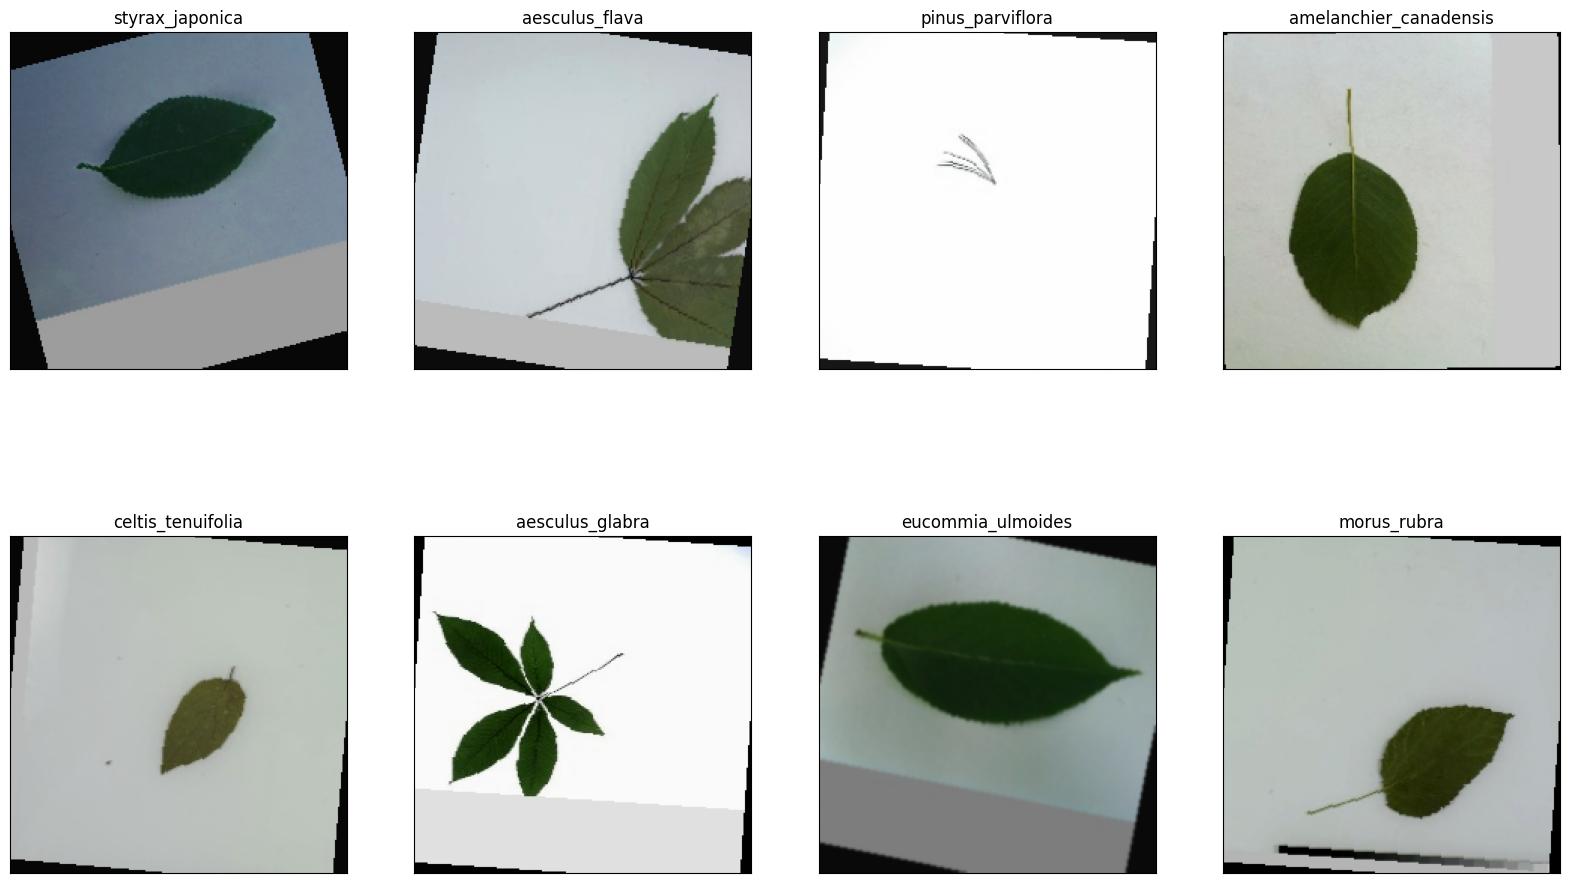

In [87]:
# 给大家展示一下数据长啥样
def im_convert(tensor):
    """展示数据"""

    image = tensor.to("cpu").clone().detach()
    image = image.numpy().squeeze()
    image = image.transpose(1, 2, 0)
    image = image.clip(0, 1)

    return image


fig = plt.figure(figsize=(20, 12))
rows = 2
columns = 4

dataiter = iter(train_loader)
inputs, classes = next(dataiter)

for idx in range(columns * rows):
    ax = fig.add_subplot(rows, columns, idx + 1, xticks=[], yticks=[])
    ax.set_title(num_to_class[int(classes[idx])])
    plt.imshow(im_convert(inputs[idx]))
plt.show()

构建模型

In [88]:
def get_net():
    num_classes = 176  # 变量名改为num_classes更规范
    net = models.resnet18(pretrained=True)

    # 修改最后一层的输出为分类数
    net.fc = nn.Linear(net.fc.in_features, num_classes)

    # 给模型添加num_classes属性，方便后续获取
    net.num_classes = num_classes  # 关键：添加类别数属性

    # 冻结非分类头的参数
    for param in net.parameters():
        param.requires_grad = False

    # 只训练分类头的参数
    for param in net.fc.parameters():
        param.requires_grad = True

    # 打印网络结构
    logging.info("Network structure:\n{}".format(net))
    return net

定义训练函数

In [89]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import logging
from tqdm import tqdm
import torchmetrics
import os
from typing import Optional, Tuple, Dict


def train(
    net: nn.Module,
    train_iter: torch.utils.data.DataLoader,
    valid_iter: torch.utils.data.DataLoader,
    num_epochs: int,
    lr: float,
    wd: float,
    devices: Tuple[torch.device],
    loss_fn: Optional[nn.Module] = None,
    model_path: str = "best_model.pth",
    patience: int = 10,  # 早停耐心值
    save_best_only: bool = True,  # 只保存最好的模型
) -> Tuple[nn.Module, Dict]:
    """
    训练模型并返回训练好的模型和训练历史

    Args:
        net: 要训练的模型
        train_iter: 训练数据加载器
        valid_iter: 验证数据加载器
        num_epochs: 训练轮数
        lr: 学习率
        wd: 权重衰减
        devices: 用于训练的设备
        loss_fn: 损失函数，如果为None则使用CrossEntropyLoss
        model_path: 模型保存路径
        patience: 早停机制的耐心值，多少轮没有提升就停止
        save_best_only: 是否只保存性能最好的模型

    Returns:
        训练好的模型和训练历史字典
    """
    # 初始化损失函数
    if loss_fn is None:
        loss_fn = nn.CrossEntropyLoss()

    # 确保保存目录存在
    os.makedirs(os.path.dirname(model_path) or ".", exist_ok=True)

    best_acc = 0.0
    counter = 0  # 早停计数器
    history = {"train_loss": [], "train_acc": [], "valid_loss": [], "valid_acc": []}

    # 数据并行处理
    net = nn.DataParallel(net, device_ids=devices).to(devices[0])

    # 优化器 - 只优化需要梯度的参数
    trainer = optim.Adam(
        (param for param in net.parameters() if param.requires_grad),
        lr=lr,
        weight_decay=wd,
    )

    # 学习率调度器
    scheduler = CosineAnnealingLR(trainer, num_epochs)

    # 初始化评估指标
    train_metrics = {
        "loss": torchmetrics.MeanMetric().to(devices[0]),
        "acc": torchmetrics.Accuracy(
            task="multiclass",
            num_classes=(
                net.module.num_classes if hasattr(net.module, "num_classes") else None
            ),
        ).to(devices[0]),
    }

    valid_metrics = {
        "loss": torchmetrics.MeanMetric().to(devices[0]),
        "acc": torchmetrics.Accuracy(
            task="multiclass",
            num_classes=(
                net.module.num_classes if hasattr(net.module, "num_classes") else None
            ),
        ).to(devices[0]),
    }

    logging.info(f"开始训练，使用设备: {devices}")
    logging.info(f"训练轮数: {num_epochs}, 初始学习率: {lr}, 权重衰减: {wd}")

    for epoch in range(num_epochs):
        # 训练阶段
        net.train()
        # 重置训练指标
        for metric in train_metrics.values():
            metric.reset()

        train_pbar = tqdm(train_iter, desc=f"Epoch {epoch + 1}/{num_epochs} [训练]")
        for X, y in train_pbar:
            X, y = X.to(devices[0], non_blocking=True), y.to(
                devices[0], non_blocking=True
            )

            # 前向传播
            y_hat = net(X)
            loss = loss_fn(y_hat, y)

            # 反向传播和优化
            trainer.zero_grad(set_to_none=True)  # 更高效的梯度清零
            loss.backward()
            trainer.step()

            # 更新指标
            train_metrics["loss"].update(loss.detach())
            train_metrics["acc"].update(y_hat.detach(), y)

            # 更新进度条
            train_pbar.set_postfix(
                {
                    "loss": f"{train_metrics['loss'].compute().item():.4f}",
                    "acc": f"{train_metrics['acc'].compute().item():.4f}",
                }
            )

        # 计算训练集指标
        train_loss = train_metrics["loss"].compute().item()
        train_acc = train_metrics["acc"].compute().item()

        # 记录训练历史
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        # 打印并记录训练结果
        log_msg = f"Epoch {epoch + 1}/{num_epochs} | 训练集 | 损失: {train_loss:.4f} | 准确率: {train_acc:.4f}"
        print(log_msg)
        logging.info(log_msg)

        # 更新学习率
        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]
        logging.debug(f"当前学习率: {current_lr:.6f}")

        # 验证阶段
        net.eval()
        # 重置验证指标
        for metric in valid_metrics.values():
            metric.reset()

        with torch.no_grad():
            valid_pbar = tqdm(valid_iter, desc=f"Epoch {epoch + 1}/{num_epochs} [验证]")
            for X, y in valid_pbar:
                X, y = X.to(devices[0], non_blocking=True), y.to(
                    devices[0], non_blocking=True
                )
                y_hat = net(X)
                loss = loss_fn(y_hat, y)

                # 更新指标
                valid_metrics["loss"].update(loss)
                valid_metrics["acc"].update(y_hat, y)

                # 更新进度条
                valid_pbar.set_postfix(
                    {
                        "loss": f"{valid_metrics['loss'].compute().item():.4f}",
                        "acc": f"{valid_metrics['acc'].compute().item():.4f}",
                    }
                )

        # 计算验证集指标
        valid_loss = valid_metrics["loss"].compute().item()
        valid_acc = valid_metrics["acc"].compute().item()

        # 记录验证历史
        history["valid_loss"].append(valid_loss)
        history["valid_acc"].append(valid_acc)

        # 打印并记录验证结果
        log_msg = f"Epoch {epoch + 1}/{num_epochs} | 验证集 | 损失: {valid_loss:.4f} | 准确率: {valid_acc:.4f}"
        print(log_msg)
        logging.info(log_msg)

        # 保存模型
        if valid_acc > best_acc:
            best_acc = valid_acc
            counter = 0  # 重置早停计数器
            # 保存模型
            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": net.state_dict(),
                    "optimizer_state_dict": trainer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict(),
                    "best_acc": best_acc,
                },
                model_path,
            )
            logging.info(f"保存新的最佳模型，准确率: {best_acc:.4f}")
        else:
            counter += 1
            logging.info(f"早停计数器: {counter}/{patience}")
            if counter >= patience:
                logging.info(f"早停触发，在第 {epoch + 1} 轮停止训练")
                break

        # 如果不是只保存最好模型，每轮都保存
        if not save_best_only:
            epoch_model_path = (
                f"{os.path.splitext(model_path)[0]}_epoch_{epoch + 1}.pth"
            )
            torch.save(net.state_dict(), epoch_model_path)

    # 加载最佳模型
    if os.path.exists(model_path):
        checkpoint = torch.load(model_path)
        net.load_state_dict(checkpoint["model_state_dict"])
        logging.info(f"训练结束，加载最佳模型，准确率: {checkpoint['best_acc']:.4f}")

    return net, history

In [90]:
res = train(
    net=get_net(),
    train_iter=train_loader,
    valid_iter=val_loader,
    num_epochs=50,
    lr=0.001,
    wd=1e-3,
    devices=[
        torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
    ],
    model_path="best_model.pth",
    patience=5,  # 早停耐心值
    save_best_only=True,  # 只保存最好的模型
)

/mnt/storage/Jagger/src/d2l-zh-pytorch-colab/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/storage/Jagger/src/d2l-zh-pytorch-colab/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/50 [训练]: 100%|██████████| 115/115 [00:21<00:00,  5.43it/s, loss=4.6642, acc=0.0838]


Epoch 1/50 | 训练集 | 损失: 4.6642 | 准确率: 0.0838


Epoch 1/50 [验证]: 100%|██████████| 29/29 [00:05<00:00,  5.63it/s, loss=3.8795, acc=0.2228]


Epoch 1/50 | 验证集 | 损失: 3.8795 | 准确率: 0.2228


Epoch 2/50 [训练]: 100%|██████████| 115/115 [00:20<00:00,  5.52it/s, loss=3.7812, acc=0.2066]


...

Epoch 43/50 | 训练集 | 损失: 1.8485 | 准确率: 0.5674


Epoch 43/50 [验证]: 100%|██████████| 29/29 [00:05<00:00,  5.41it/s, loss=1.4400, acc=0.6110]


Epoch 43/50 | 验证集 | 损失: 1.4400 | 准确率: 0.6110


Epoch 44/50 [训练]:  38%|███▊      | 44/115 [00:08<00:14,  5.05it/s, loss=1.8650, acc=0.5632]


KeyboardInterrupt: 